In [ ]:
!pip install tensorflow

In [2]:
# Importing the libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [1]:
num_words = 10_000  # keep the 10k most frequent tokens


In [3]:
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=num_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
train_data.shape, test_data.shape

((25000,), (25000,))

In [5]:
train_labels.shape, test_labels.shape

((25000,), (25000,))

In [6]:
# Fonction de vectorisation (one-hot encoding)
def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1  #set specific indices of results[i] to 1s
    return results

In [7]:
# Conversion des séquences en matrices binaires
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [8]:
#Normalisation des images pour conserver l'essentielle
y_train = np.array(train_labels).astype('float32')
y_test = np.array(test_labels).astype('float32')

In [9]:
y_train, y_test

(array([1., 0., 0., ..., 0., 1., 0.], dtype=float32),
 array([0., 1., 1., ..., 0., 0., 0.], dtype=float32))

In [12]:
# Création d'un ensemble de validation
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

In [13]:
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [14]:
print(x_val.shape, partial_x_train.shape)
print(y_val.shape, partial_y_train.shape)

(10000, 10000) (15000, 10000)
(10000,) (15000,)


In [15]:
print("Ensemble d'entraînement :", partial_x_train.shape)
print("Ensemble de validation :", x_val.shape)
print("Ensemble de test :", x_test.shape)

Ensemble d'entraînement : (15000, 10000)
Ensemble de validation : (10000, 10000)
Ensemble de test : (25000, 10000)


## **2. Construction du modèle**

In [16]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(10000,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Notre reseau comporte 160305 paramètres

## **

In [18]:
history = model.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.7480 - loss: 0.5531 - val_accuracy: 0.8602 - val_loss: 0.4247
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.8905 - loss: 0.3448 - val_accuracy: 0.8772 - val_loss: 0.3313
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.9147 - loss: 0.2561 - val_accuracy: 0.8867 - val_loss: 0.2901
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9327 - loss: 0.2048 - val_accuracy: 0.8876 - val_loss: 0.2771
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9415 - loss: 0.1732 - val_accuracy: 0.8835 - val_loss: 0.2925
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9524 - loss: 0.1438 - val_accuracy: 0.8869 - val_loss: 0.2832
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9606 - loss: 0.1247 - val_accuracy: 0.8843 - val_loss: 0.3052
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9695 - loss: 0.1053 - val_accuracy: 0.8733 -

In [19]:
loss, accuracy = model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8570 - loss: 0.6229


In [20]:
print('Test loss:', round(loss, 2))
print('Test accuracy:', round(accuracy,2))

Test loss: 0.62
Test accuracy: 0.86


Notre modèle à un accuracy de 86%, il arrive à faire de prédiction correcte et minimise les pertes, ici on a une perte de 0.62

## **4. Evaluate the Model:**

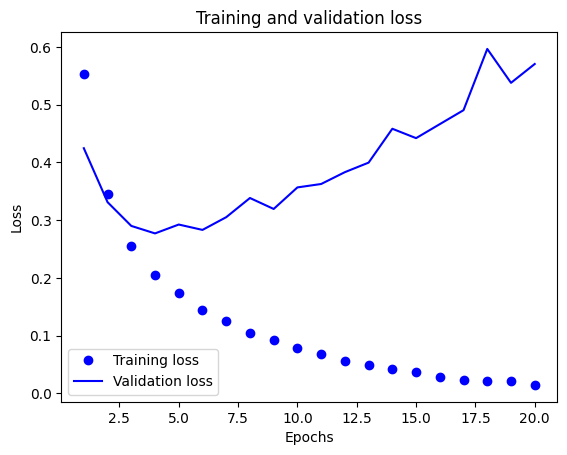

In [21]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

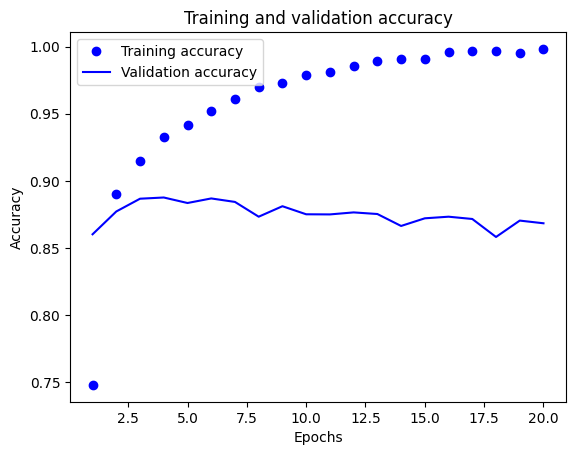

In [22]:
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Les courbes montrent un phénomène de surapprentissage à partir de la 4ᵉ ou 5ᵉ époque. La perte d'entraînement diminue continuellement tandis que la perte de validation augmente après avoir atteint un minimum d'environ 0,28. De même, la précision d'entraînement atteint presque 100 %, alors que la précision de validation plafonne autour de 89 % puis diminue légèrement. Cela indique que le modèle mémorise les données d'entraînement au lieu de généraliser correctement sur de nouvelles données. Le nombre optimal d'époques est donc d'environ 4 à 5.

In [25]:
new_model = Sequential([
    Dense(16, activation='relu', input_shape=(10000,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

new_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

In [26]:
# Réentraînement avec le nombre optimal d'époques
history = new_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=5,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.7670 - loss: 0.5514 - val_accuracy: 0.8656 - val_loss: 0.4196
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8889 - loss: 0.3443 - val_accuracy: 0.8824 - val_loss: 0.3252
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9175 - loss: 0.2545 - val_accuracy: 0.8885 - val_loss: 0.2896
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9283 - loss: 0.2073 - val_accuracy: 0.8872 - val_loss: 0.2766
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9459 - loss: 0.1681 - val_accuracy: 0.8858 - val_loss: 0.2757


In [27]:
# Évaluation sur l'ensemble de test
loss, accuracy = new_model.evaluate(x_test, y_test)
print("Test Loss :", round(loss,2))
print("Test Accuracy :", round(accuracy,2))

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8809 - loss: 0.2931
Test Loss : 0.29
Test Accuracy : 0.88


Le modèle a atteint une performance maximale avec un accuracy de 88% contrairement à l'ancien model et un perte de 0.29

## **5. Analyze Results**

### **Observations**
La précision d'entraînement est presque parfaite (≈ 99,8 % à 100 %).
La perte d'entraînement est extrêmement faible (proche de 0).
En revanche, la précision de validation reste autour de 85-88 % sans amélioration notable.
La perte de validation augmente progressivement de 0.27 à 0.59.

Ces résultats indiquent que le modèle surapprend (overfitting) : il mémorise très bien les données d'entraînement mais généralise moins bien sur des données jamais vues. L'écart important entre les performances d'entraînement et de validation en est la preuve.

**Résultat final**

Après après la mise en place du nouveau model:

* Perte (Test Loss) : 0.29
* Précision (Test Accuracy) : 0.88 (88 %)
**Conclusion**

Le modèle obtient une précision quasi parfaite sur les données d'entraînement, mais seulement 88 % sur les données de validation et 94% sur les données de test. Le modèle conserve une bonne capacité de classification avec une précision finale de 88 % sur l'ensemble de test et une perte de 0.29.